<a href="https://colab.research.google.com/github/qjpbtuzara-ai/CPE311-CPE22S3/blob/main/Tuzara_HOA9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tuzara, John Paul B. <br>
Course and Section: CPE311-CPE22S3 <br>
Date: 3/9/26 <br>
Instructor: Engr. Neal Barton James Matira

### Procedures

###9.4 Introduction to Seaborn

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('earthquakes-1.csv')

In [ ]:
quakes.assign(
time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
"parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)

,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


<Axes: xlabel='magType', ylabel='mag'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


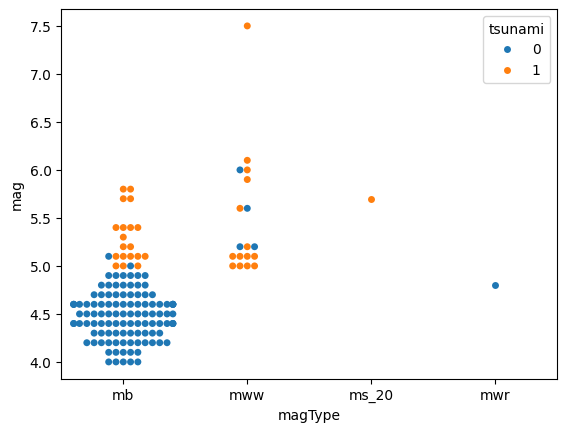

In [ ]:

sns.swarmplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"')
)

<Axes: >

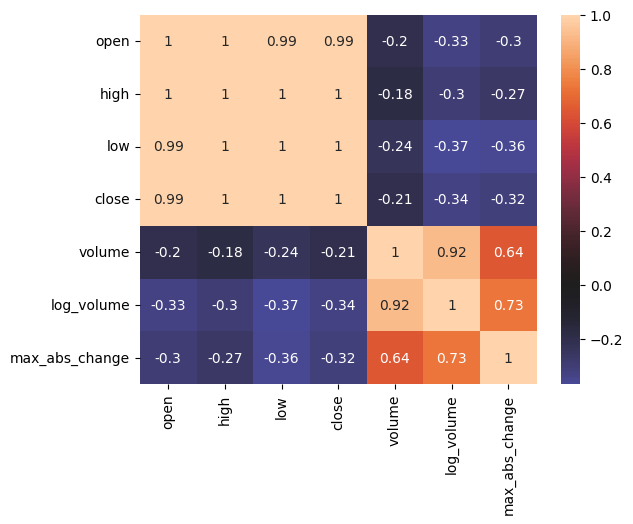

In [ ]:
sns.heatmap(
fb.sort_index().assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).corr(),
annot=True, center=0
)

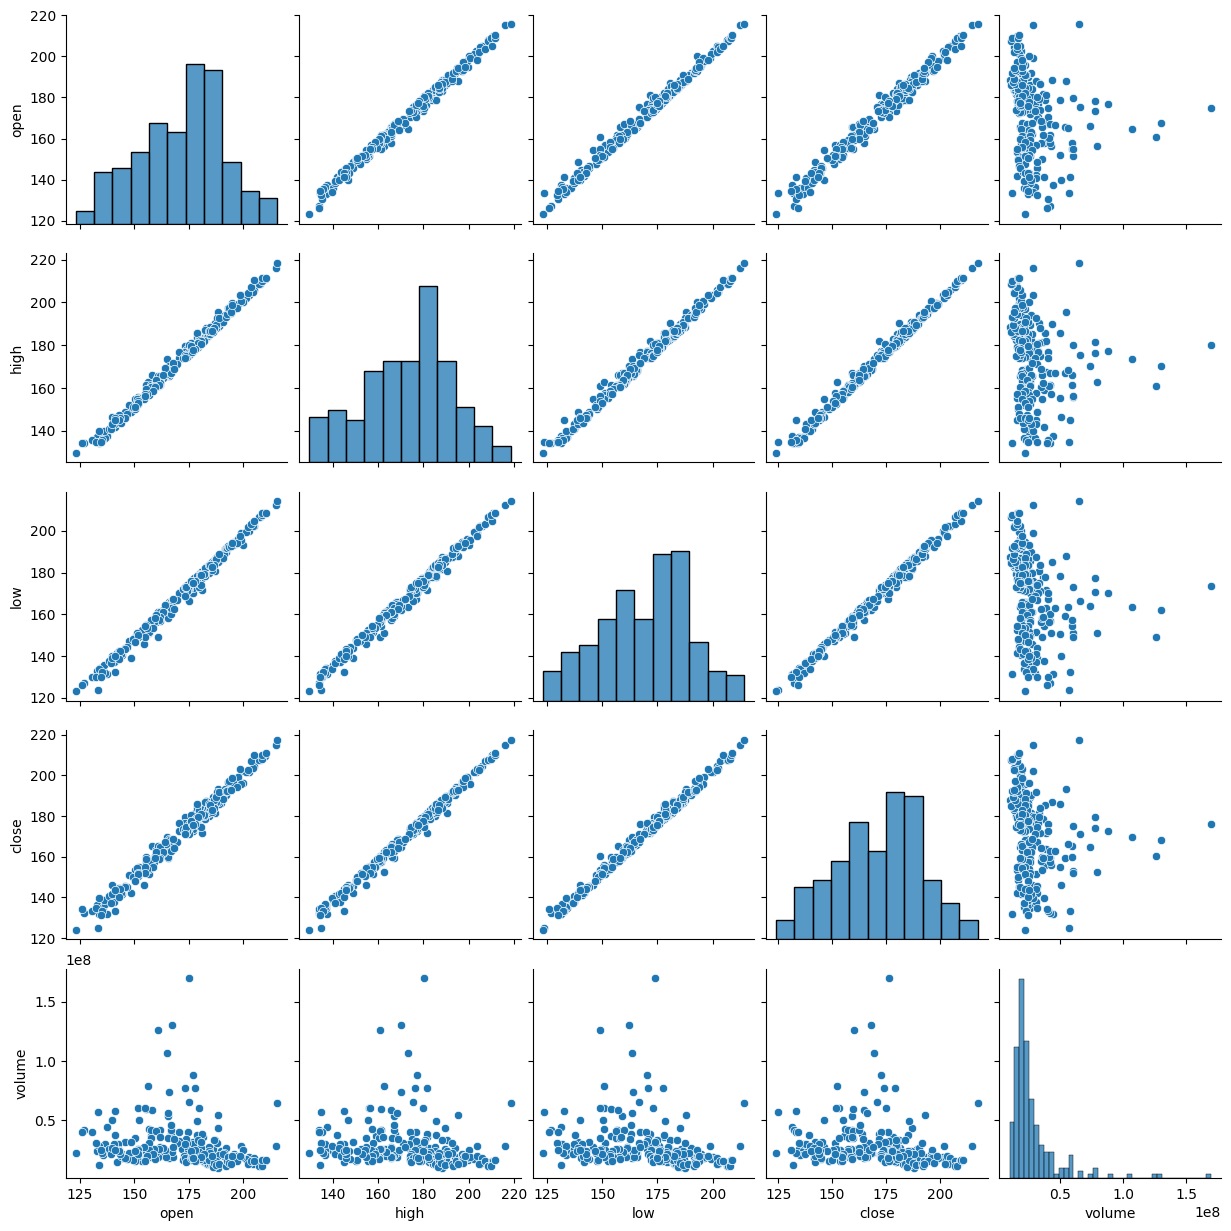

In [ ]:
sns.pairplot(fb)

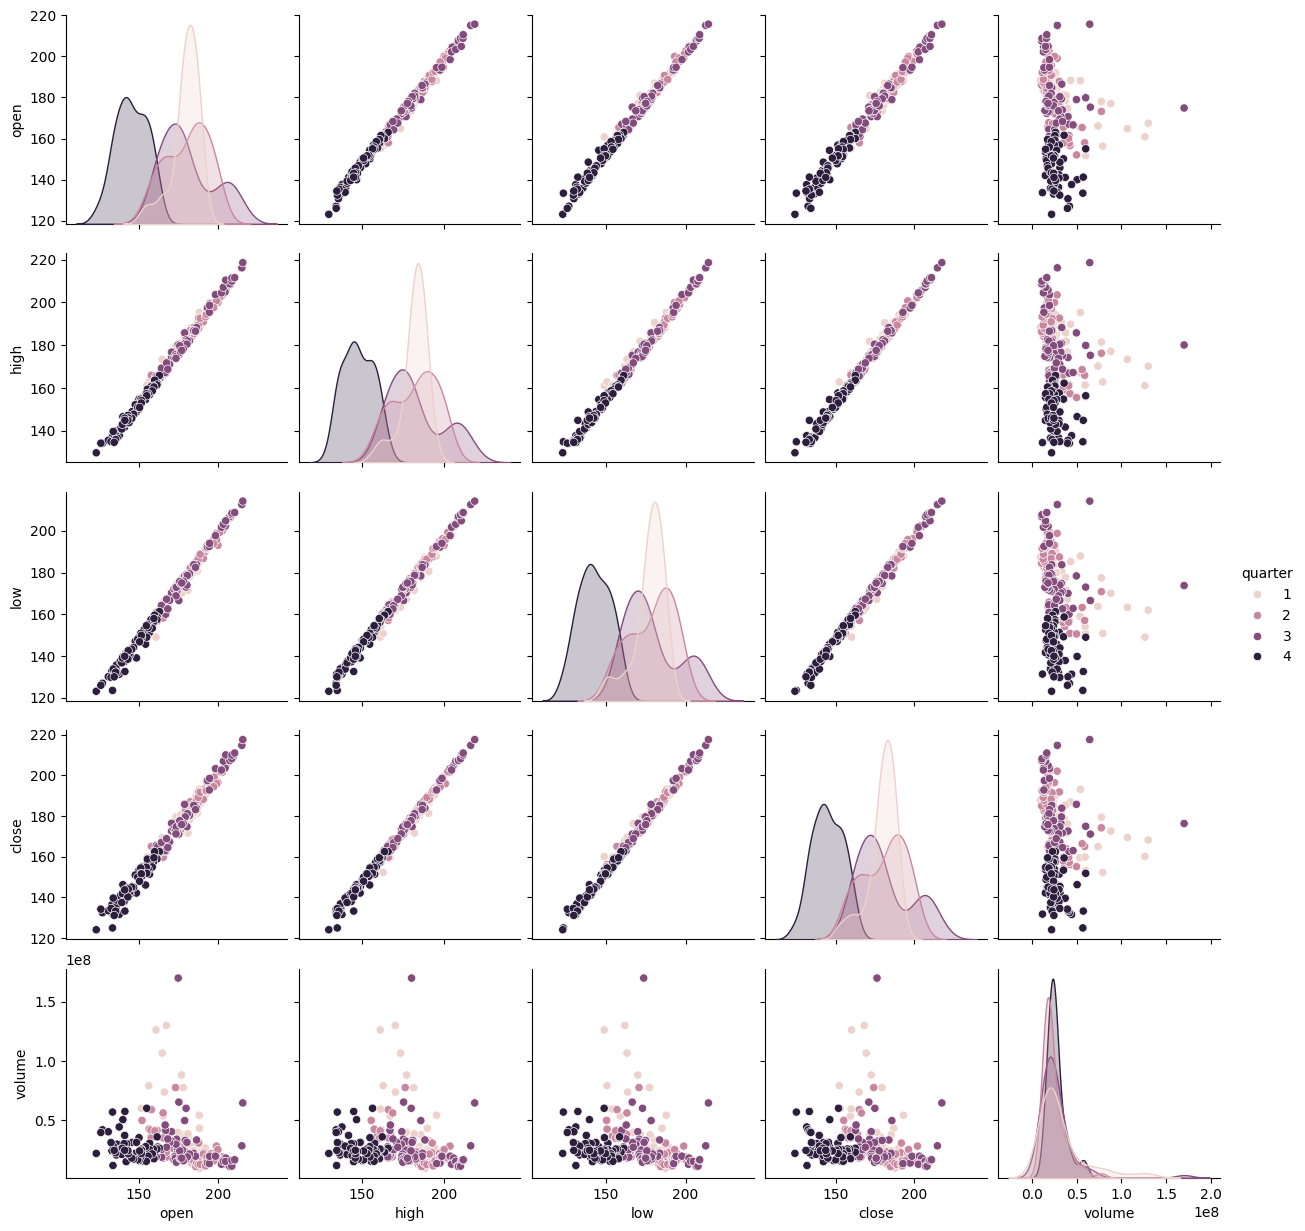

In [ ]:
sns.pairplot(
fb.assign(quarter=lambda x: x.index.quarter),
diag_kind='kde',
hue='quarter'
)

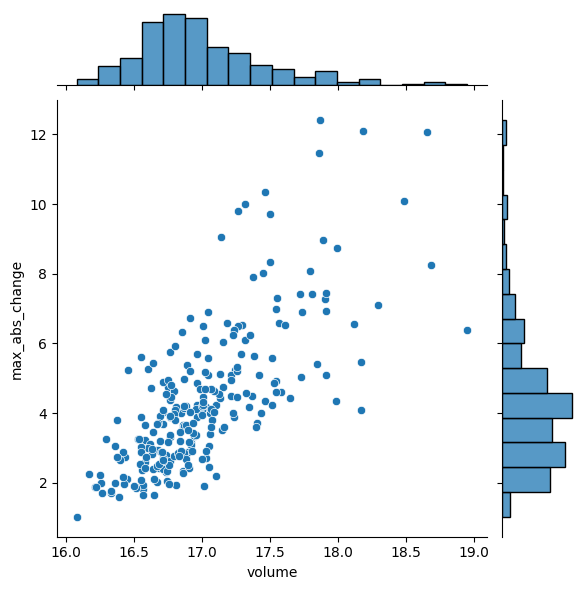

In [ ]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

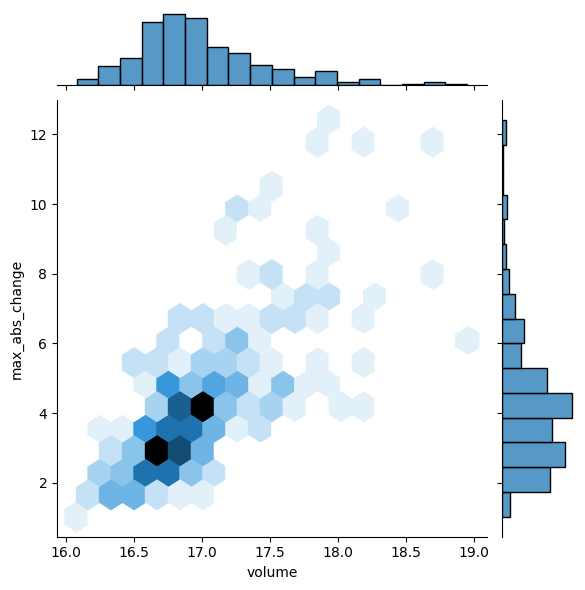

In [ ]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='hex',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

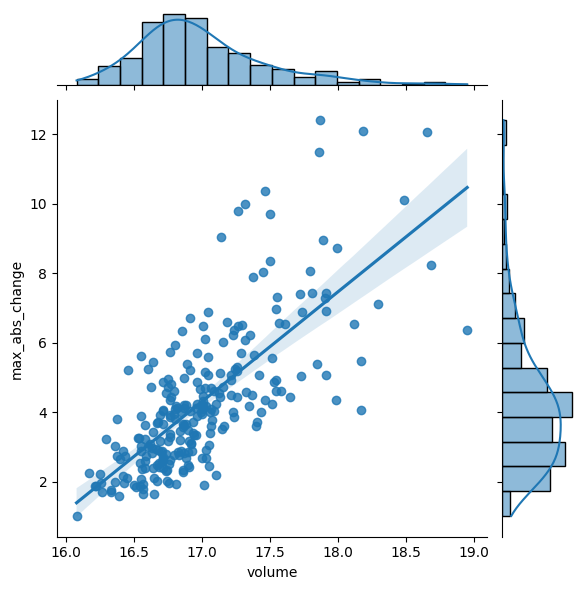

In [ ]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='reg',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

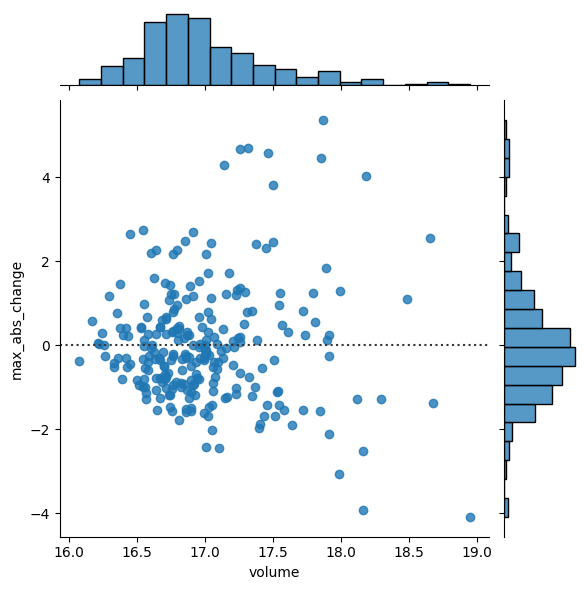

In [ ]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='resid',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

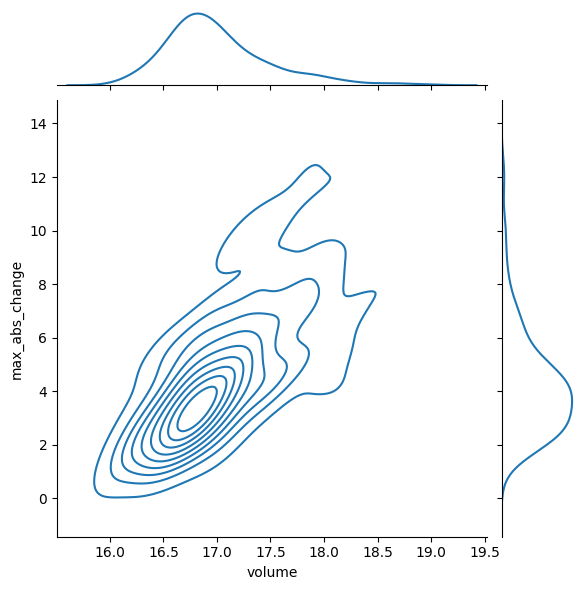

In [ ]:
sns.jointplot(
    x='volume',
    y='max_abs_change',
    kind='kde',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    )
)

In [ ]:
fb_reg_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).iloc[:,-2:]
import itertools

In [ ]:
iterator = itertools.repeat("I'm an iterator", 1)
for i in iterator:
  print(f'-->{i}')
  print('This printed once because the iterator has been exhausted')
for i in iterator:
  print(f'-->{i}')

-->I'm an iterator
This printed once because the iterator has been exhausted


In [ ]:
iterable = list(itertools.repeat("I'm an iterable", 1))
for i in iterable:
  print(f'-->{i}')
  print('This prints again because it\'s an iterable:')
for i in iterable:
  print(f'-->{i}')

-->I'm an iterable
This prints again because it's an iterable:
-->I'm an iterable


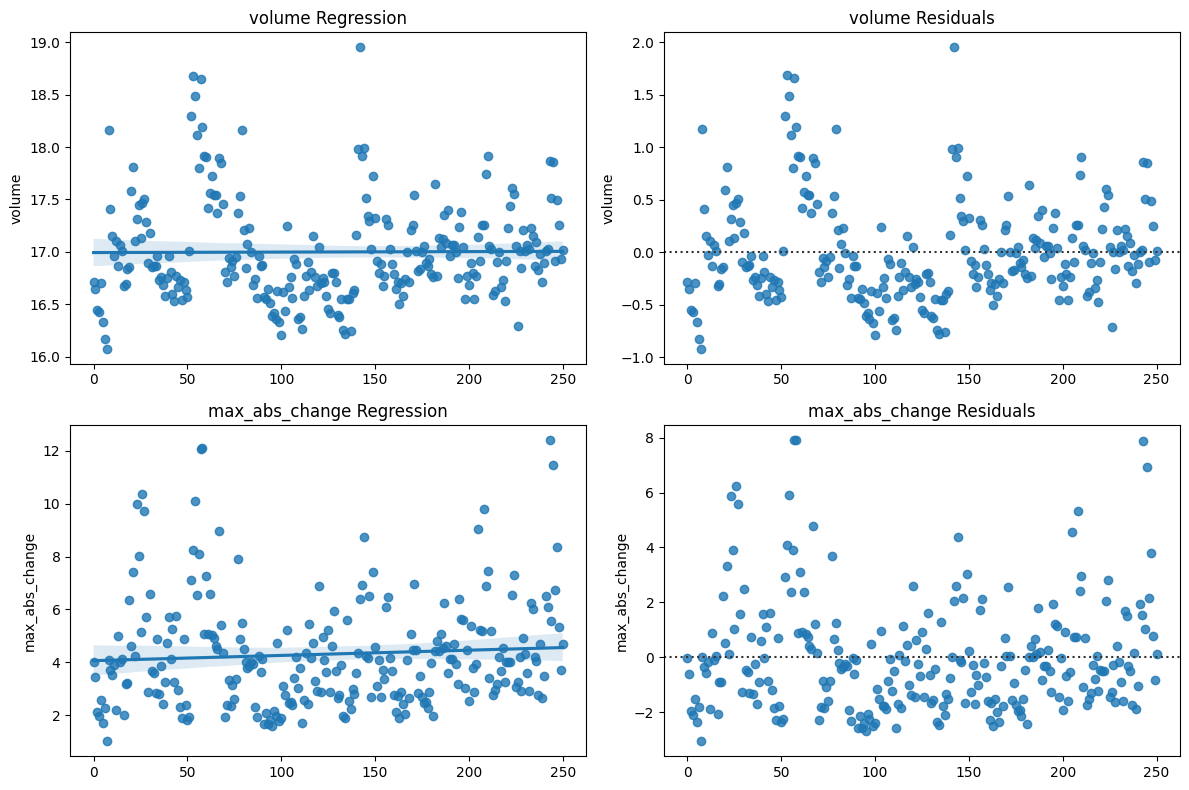

In [ ]:
import numpy as np

def reg_resid_plots(data):

    plot_data = data.reset_index(drop=True)
    cols = plot_data.columns
    n_cols = len(cols)


    fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4 * n_cols), squeeze=False)

    x_values = plot_data.index

    for i, col in enumerate(cols):
        sns.regplot(x=x_values, y=plot_data[col], ax=axes[i][0])
        axes[i][0].set_title(f'{col} Regression')

        sns.residplot(x=x_values, y=plot_data[col], ax=axes[i][1])
        axes[i][1].set_title(f'{col} Residuals')

    plt.tight_layout()
    plt.show()

#from reg_resid_plotimport reg_resid_plots
reg_resid_plots(fb_reg_data)


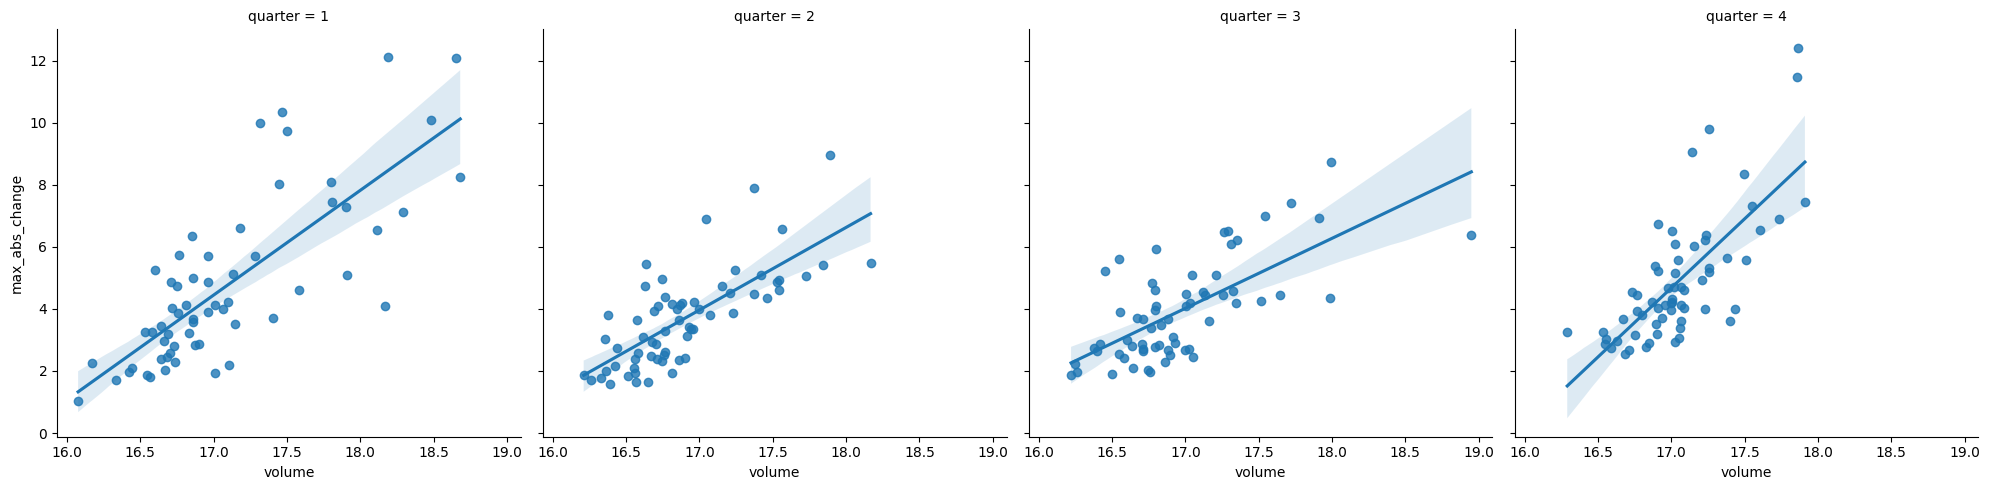

In [ ]:
sns.lmplot(
x='volume',
y='max_abs_change',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low,
quarter=lambda x: x.index.quarter
),
col='quarter'
)


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

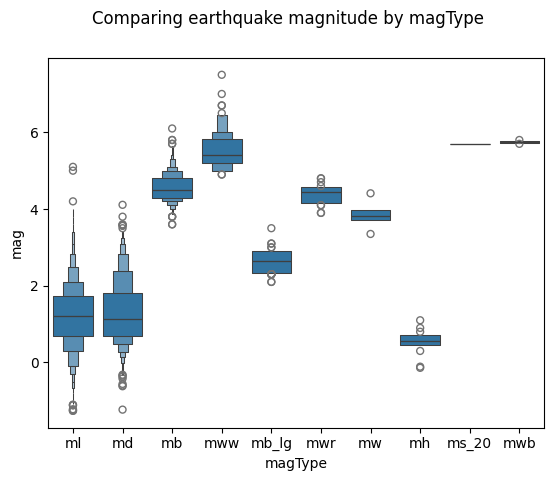

In [ ]:
sns.boxenplot(
x='magType', y='mag', data=quakes[['magType', 'mag']]
)
plt.suptitle('Comparing earthquake magnitude by magType')

/tmp/ipykernel_186/603559778.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

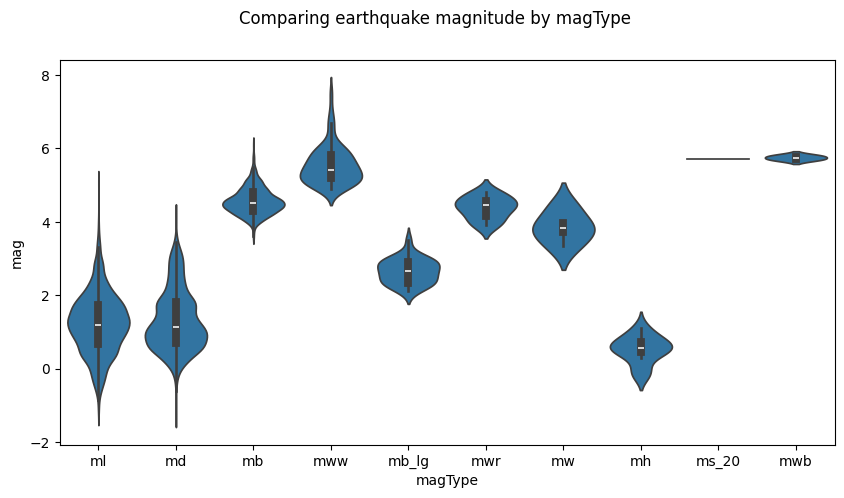

In [ ]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
x='magType', y='mag', data=quakes[['magType', 'mag']],
ax=axes, scale='width' # all violins have same width
)
plt.suptitle('Comparing earthquake magnitude by magType')

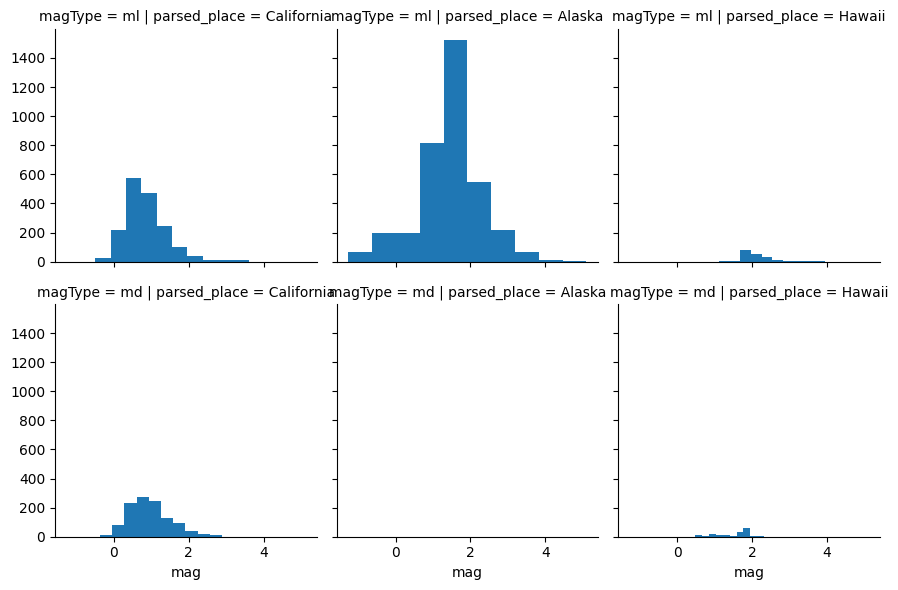

In [ ]:
g = sns.FacetGrid(
quakes[
(quakes.parsed_place.isin([
'California', 'Alaska', 'Hawaii'
]))\
& (quakes.magType.isin(['ml', 'md']))
],
row='magType',
col='parsed_place'
)
g = g.map(plt.hist, 'mag')

###9.5 Formatting Plots

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

fb = pd.read_csv(
    'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)


Text(0, 0.5, 'price ($)')

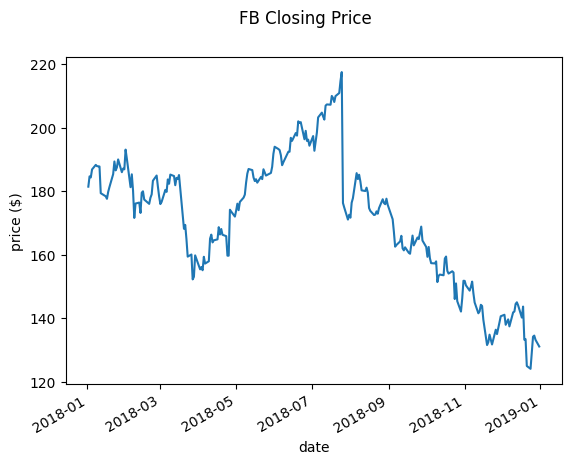

In [ ]:
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')


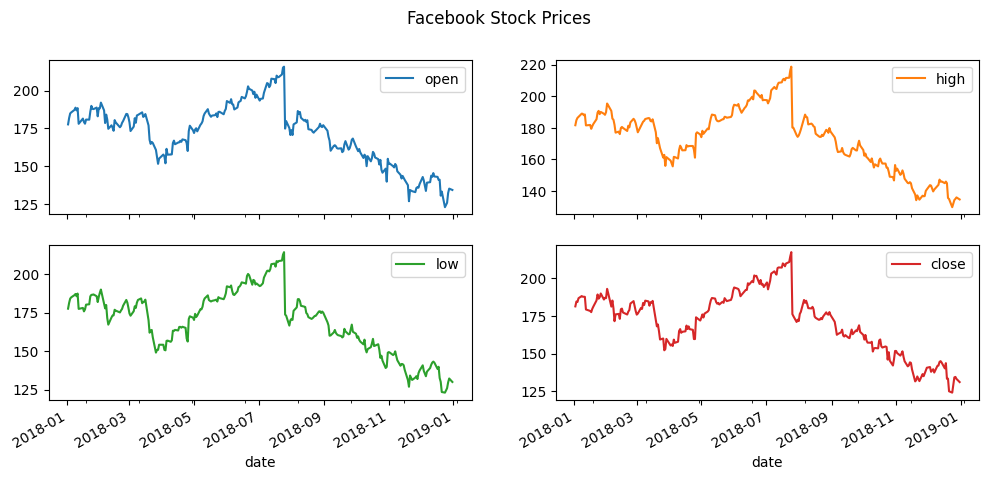

In [ ]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.suptitle('Facebook Stock Prices')
plt.show()


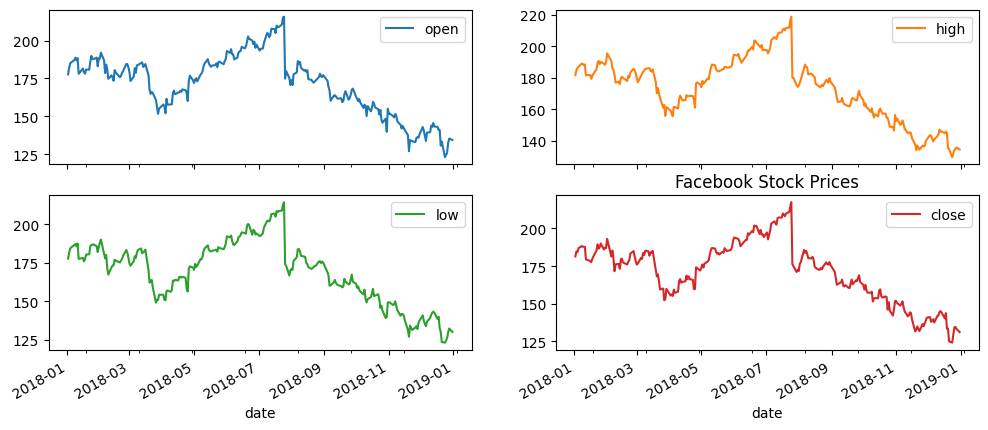

In [ ]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.title('Facebook Stock Prices')
plt.show()


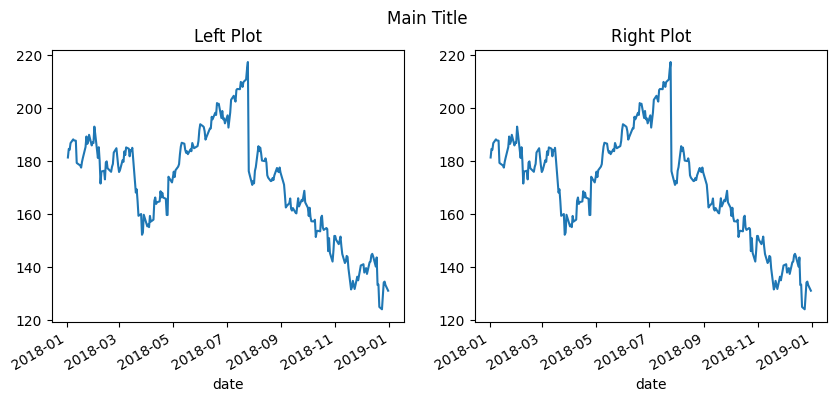

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fb.close.plot(ax=axes[0], title='Left Plot')
fb.close.plot(ax=axes[1], title='Right Plot')
plt.suptitle('Main Title')
plt.show()


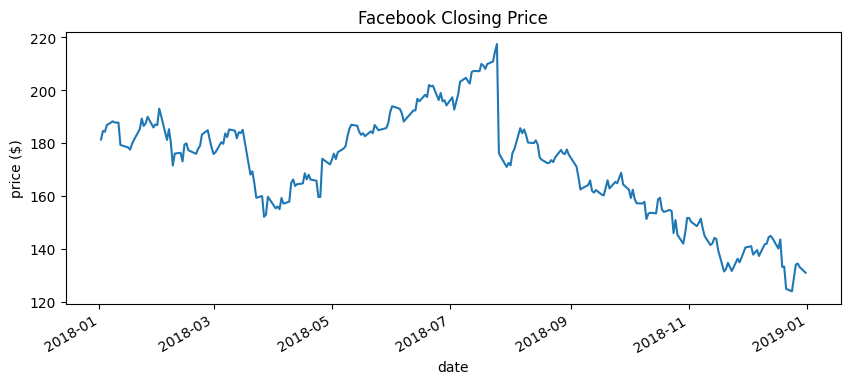

In [ ]:
from matplotlib import ticker

ax = fb.close.plot(figsize=(10, 4), title='Facebook Closing Price')
ax.set_ylabel('price ($)')
ax.yaxis.set_major_formatter(ticker.EngFormatter())


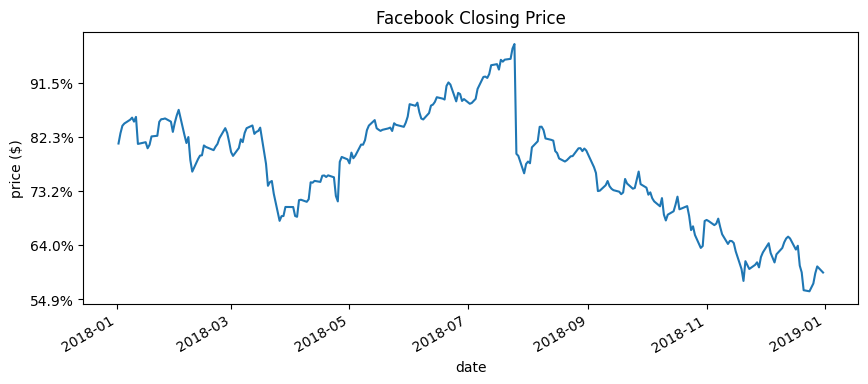

In [ ]:
from matplotlib import ticker

ax = fb.low.plot(figsize=(10, 4), title='Facebook Closing Price')
ax.set_ylabel('price ($)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=fb.high.max()))


Text(0, 0.5, 'percent of highest price ($218.62)')

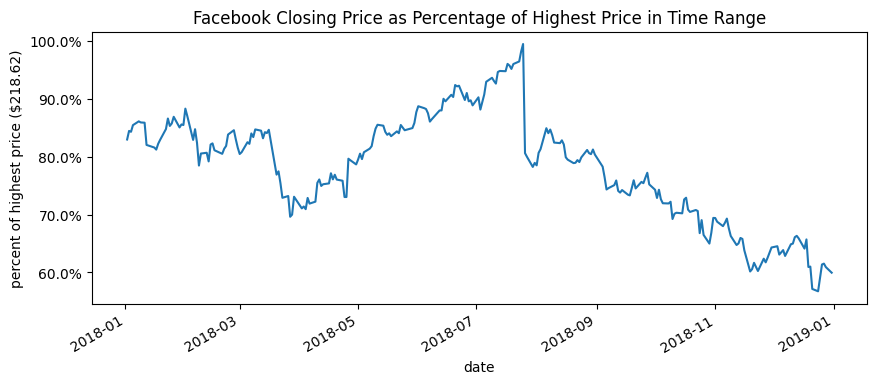

In [ ]:
from matplotlib import ticker

ax = fb.close.plot(
    figsize=(10, 4),
    title='Facebook Closing Price as Percentage of Highest Price in Time Range'
)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=fb.high.max()))
ax.set_yticks([
    fb.high.max() * pct for pct in np.linspace(0.6, 1, num=5)
])
ax.set_ylabel(f'percent of highest price (${fb.high.max()})')


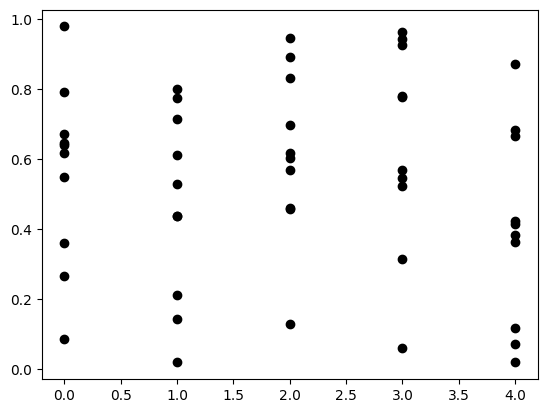

In [ ]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')


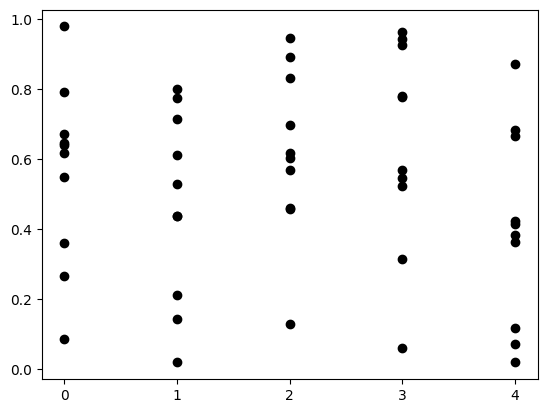

In [ ]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))


###9.6 Customizing Visualizations

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fb = pd.read_csv(
    'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)


array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

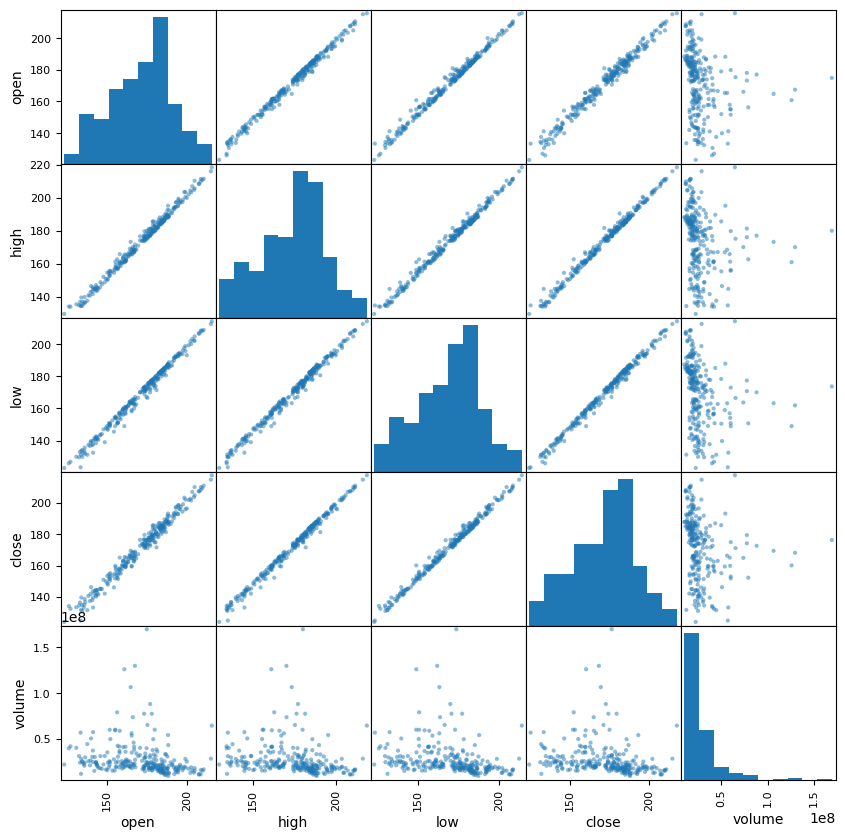

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10, 10))


<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

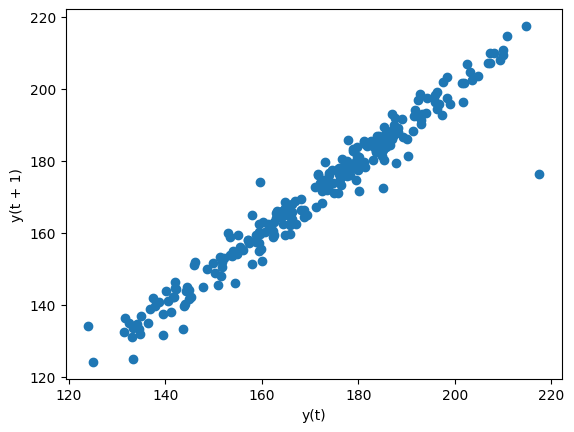

In [ ]:
from pandas.plotting import lag_plot
lag_plot(fb.close)


<Axes: xlabel='y(t)', ylabel='y(t + 5)'>

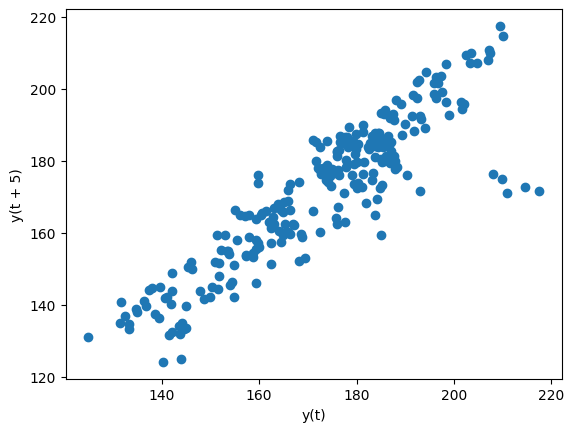

In [ ]:
lag_plot(fb.close, lag=5)


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

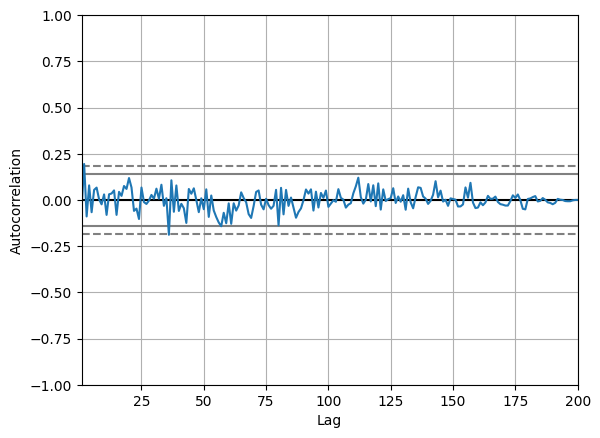

In [ ]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0) # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

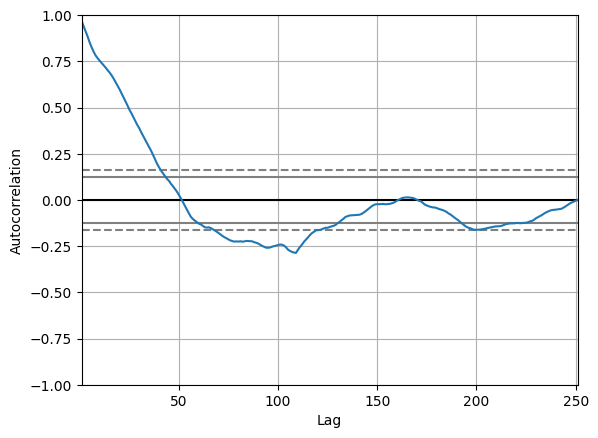

In [ ]:
autocorrelation_plot(fb.close)


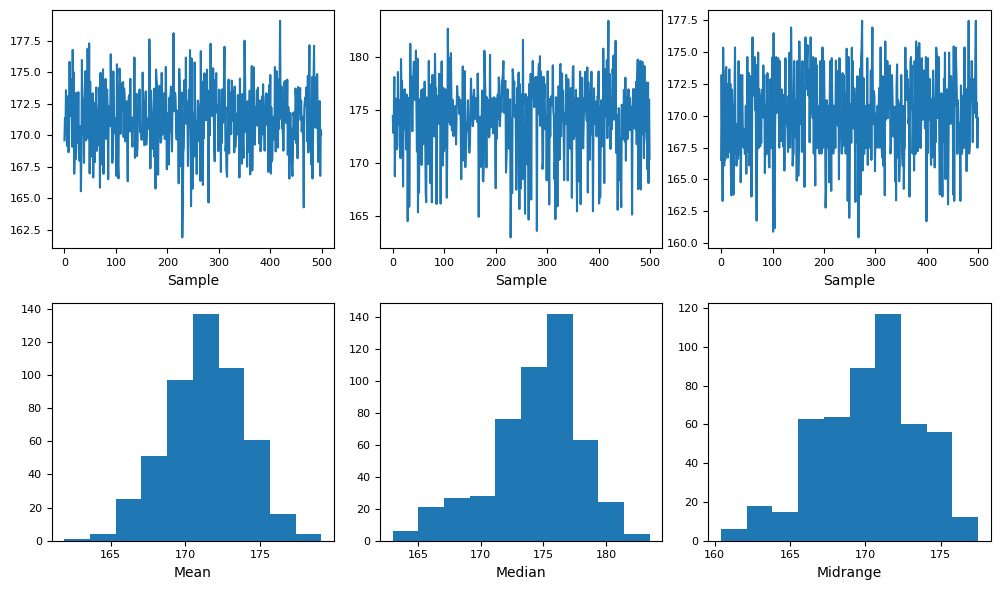

In [ ]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.close, fig=plt.figure(figsize=(10, 6)))


###Data Analysis

At 9.4; in my analysis of the first module, I used Seaborn to explore the underlying structures within the Facebook stock and earthquake datasets. By implementing pairplot(), I discovered a near-perfect linear correlation between the various stock price variables, while the kde diagonal allowed me to identify distinct peaks in trading activity tied to specific fiscal quarters. When I experimented with jointplot(), I found that changing the "kind" parameter—from scatter and hex to regression and KDE—completely shifted my perspective from individual outliers to the central density of the data; specifically, the hexbin plots were essential for resolving overplotting in high-volume areas. Finally, my work with boxenplot() and violinplot() provided a far more detailed view of earthquake magnitudes than a standard box plot could offer. I noted
that the wider sections of the violins for ml magnitude types indicated a high frequency of mid-range events, and by using FacetGrid, I was able to confirm that Alaska consistently shows a broader range of seismic intensity compared to Hawaii.

At 9.5, I focused on transforming these raw visualizations into professional-grade figures using Seaborn and Matplotlib’s formatting tools. I learned to differentiate between plt.title() for individual plots and plt.suptitle() for providing an overarching context to a set of subplots, which kept my layouts organized and readable. I found the ticker module particularly powerful for financial data; I applied the EngFormatter to stock volumes to make large numbers more digestible and used the PercentFormatter to view the Facebook closing price relative to its annual high. This allowed me to identify specific periods where the stock dropped by 30-40%, a trend that wasn't as immediately obvious on a standard dollar scale. I also utilized the MultipleLocator to clean up my x-axes, forcing ticks to appear only at integer intervals, which significantly reduced visual clutter and improved the overall clarity of my charts.

At 9.6, in the final module, I utilized the pandas.plotting subpackage to run diagnostic checks on my time-series data. I started with a scatter_matrix to get a bird's-eye view of how all the Facebook features interacted, identifying which variables moved in sync. To investigate serial dependency, I generated lag_plot() visualizations; the tight grouping of points along the diagonal when plotting y(t) against y(t+1) confirmed for me that the stock price is non-random and highly autocorrelated. I further validated this by creating an autocorrelation_plot(), where the Facebook data curve remained significantly above the threshold of randomness, unlike the white noise sample I tested. Finally, I performed a bootstrap_plot() to verify the stability of my summary statistics. By repeatedly resampling the closing prices, I was able to visualize the distribution of the mean and median, which proved to me that the stock's central tendency is statistically robust and not skewed by just a few outlier trading days.




###Supplementary Activity

Using the CSV files provided and what we have learned so far in this module complete the following exercises:

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.
2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)
3. Fill in the area between the bounds in the plot from exercise #2.
4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.
5. Using the Facebook stock price data, annotate the following three events on a line plot of the closing price:
* Disappointing user growth announced after close on July 25, 2018
* Cambridge Analytica story breaks on March 19, 2018 (when it affected the market)
* FTC launches investigation on March 20, 2018
6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

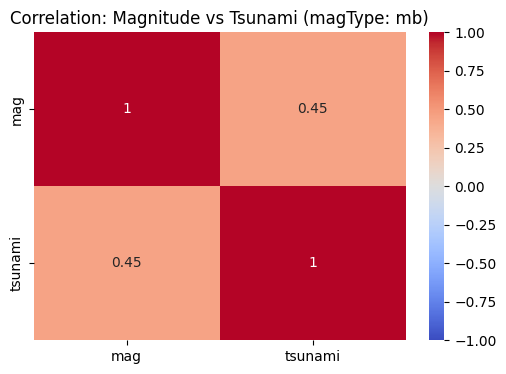

In [63]:
quakes_mb = quakes[quakes['magType'] == 'mb']

corr_matrix = quakes_mb[['mag', 'tsunami']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Correlation: Magnitude vs Tsunami (magType: mb)')
plt.show()




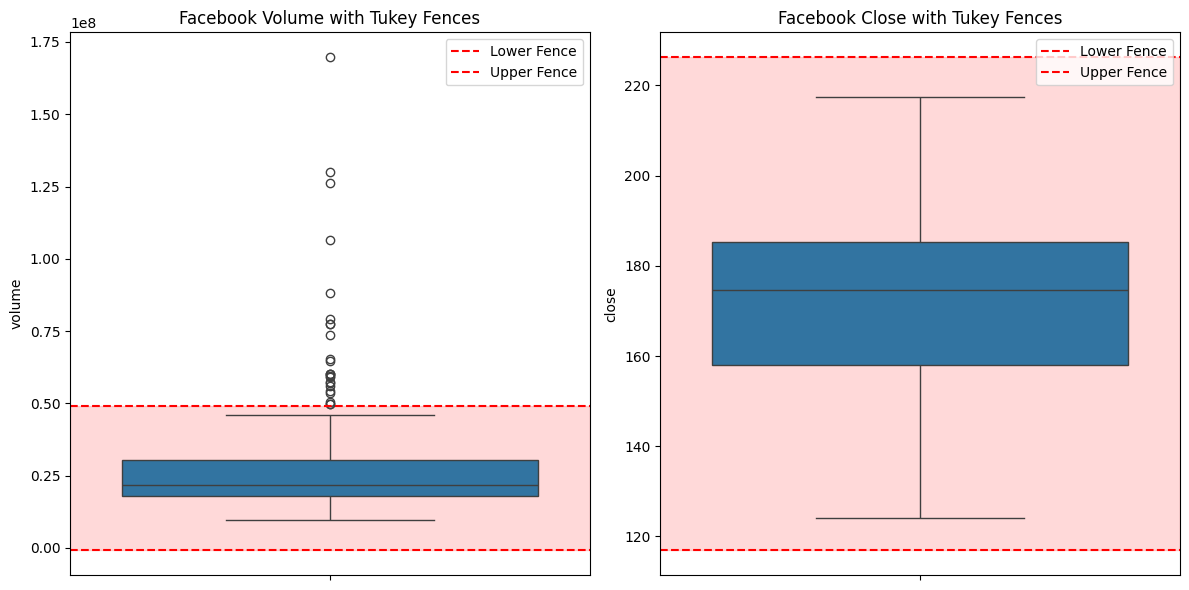

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col in zip(axes, ['volume', 'close']):
    sns.boxplot(y=fb[col], ax=ax)

    q1 = fb[col].quantile(0.25)
    q3 = fb[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    ax.axhline(lower_bound, color='red', linestyle='--', label='Lower Fence')
    ax.axhline(upper_bound, color='red', linestyle='--', label='Upper Fence')

    #3
    ax.axhspan(lower_bound, upper_bound, color='red', alpha=0.15)

    ax.set_title(f'Facebook {col.capitalize()} with Tukey Fences')
    ax.legend()

plt.tight_layout()
plt.show()

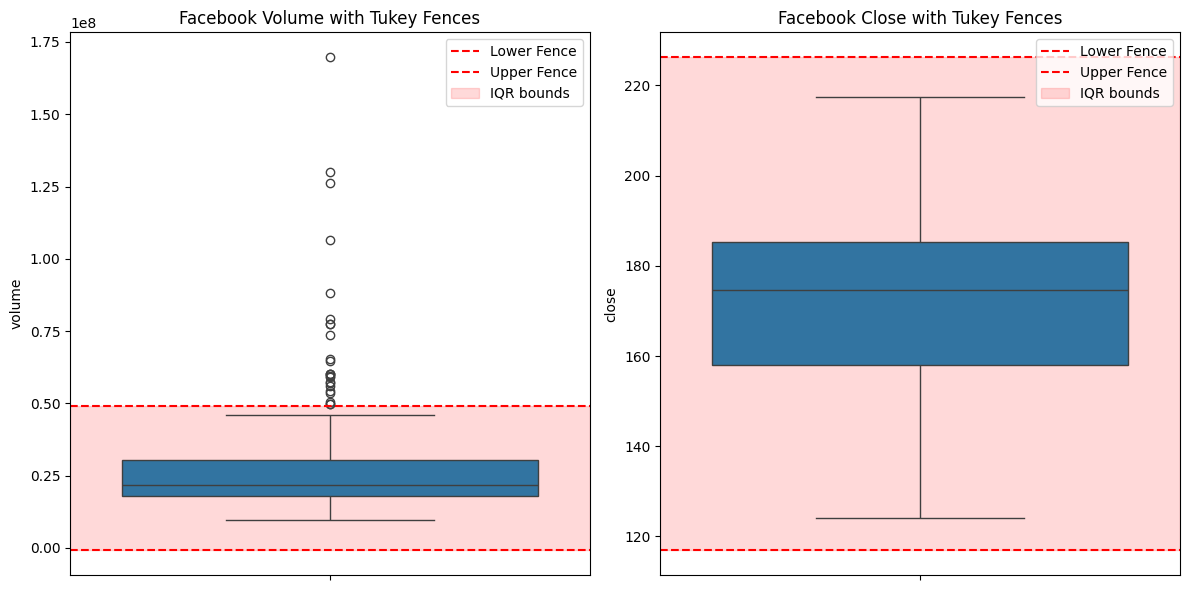

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col in zip(axes, ['volume', 'close']):
    sns.boxplot(y=fb[col], ax=ax)

    q1 = fb[col].quantile(0.25)
    q3 = fb[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    ax.axhline(lower_bound, color='red', linestyle='--', label='Lower Fence')
    ax.axhline(upper_bound, color='red', linestyle='--', label='Upper Fence')

    ax.axhspan(lower_bound, upper_bound, color='red', alpha=0.15, label='IQR bounds')

    ax.set_title(f'Facebook {col.capitalize()} with Tukey Fences')
    ax.legend()

plt.tight_layout()
plt.show()

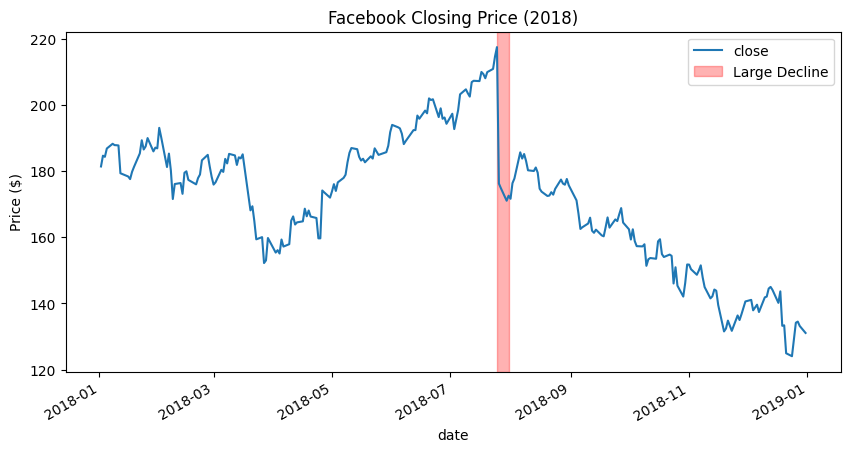

In [65]:
ax = fb['close'].plot(figsize=(10, 5), title='Facebook Closing Price (2018)')

# Shade the specific date range
ax.axvspan('2018-07-25', '2018-07-31', color='red', alpha=0.3, label='Large Decline')

plt.ylabel('Price ($)')
plt.legend()
plt.show()


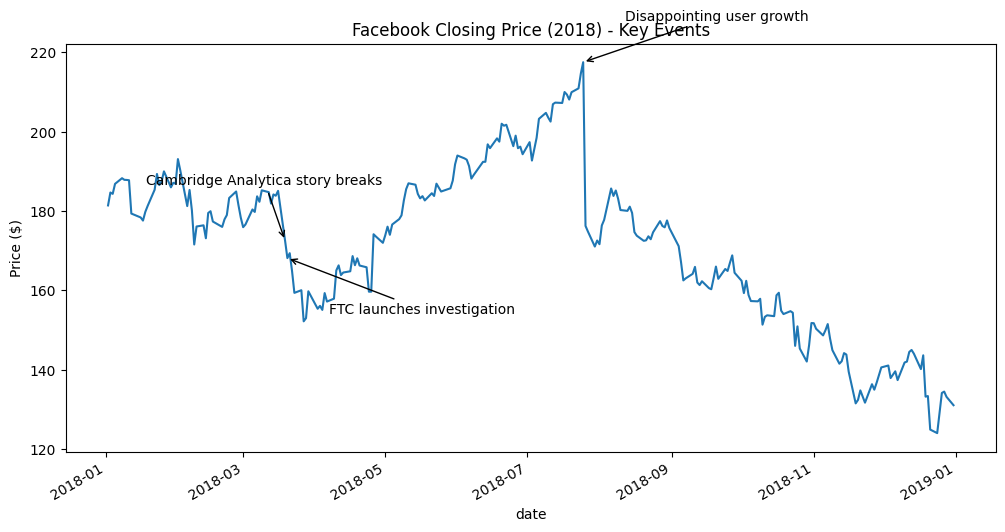

In [66]:
ax = fb['close'].plot(figsize=(12, 6), title='Facebook Closing Price (2018) - Key Events')

events = [
    ('2018-07-25', 'Disappointing user growth'),
    ('2018-03-19', 'Cambridge Analytica story breaks'),
    ('2018-03-20', 'FTC launches investigation')
]

offsets = [
    (30, 30),   #July 25
    (-100, 40), #March 19
    (30, -40)   #March 20
]

for (date, event_text), (x_offset, y_offset) in zip(events, offsets):
    y_value = fb['close'][date]

    ax.annotate(
        event_text,
        xy=(pd.to_datetime(date), y_value),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='black')
    )

plt.ylabel('Price ($)')
plt.show()

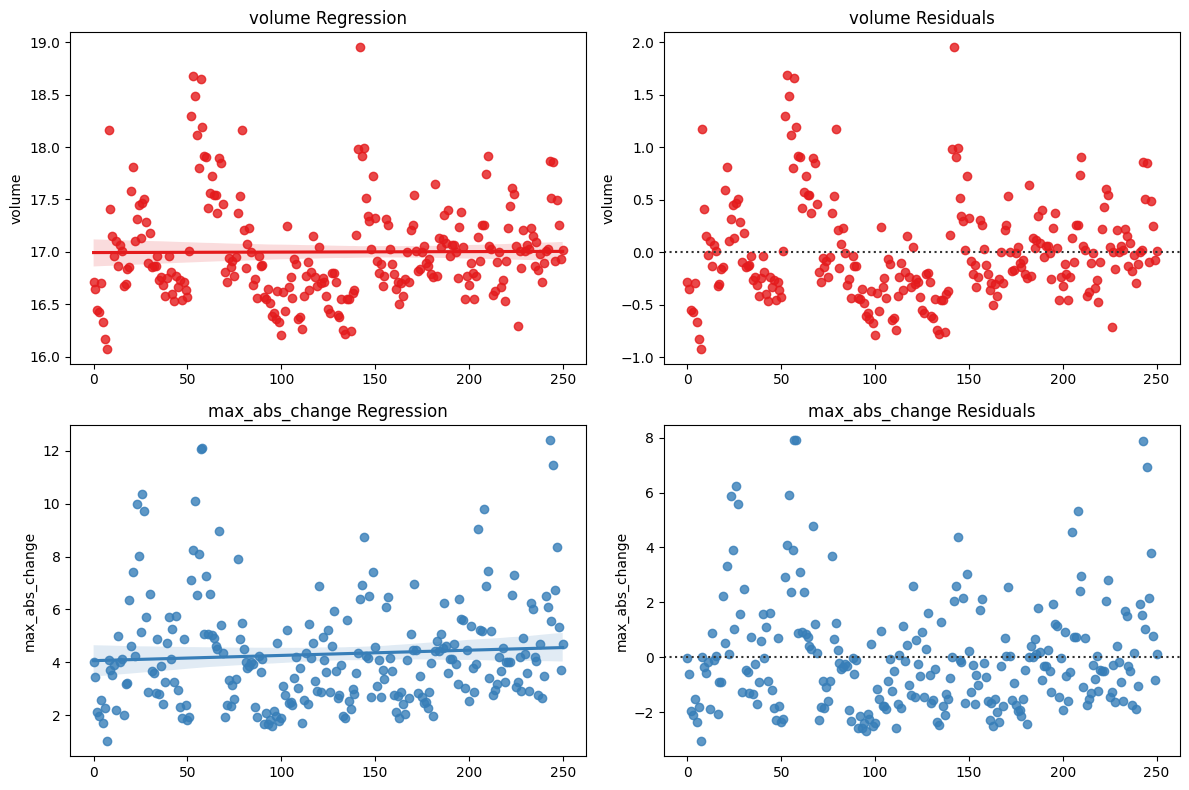

In [67]:
import matplotlib.cm as cm

def reg_resid_plots(data):

    plot_data = data.reset_index(drop=True)
    cols = plot_data.columns
    n_cols = len(cols)

    fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4 * n_cols), squeeze=False)
    x_values = plot_data.index

    cmap = plt.get_cmap('Set1')

    for i, col in enumerate(cols):
        color = cmap(i % cmap.N)

        sns.regplot(x=x_values, y=plot_data[col], ax=axes[i][0], color=color)
        axes[i][0].set_title(f'{col} Regression')

        sns.residplot(x=x_values, y=plot_data[col], ax=axes[i][1], color=color)
        axes[i][1].set_title(f'{col} Residuals')

    plt.tight_layout()
    plt.show()

b_reg_data = fb[['volume', 'close']].copy()
reg_resid_plots(fb_reg_data)


###Summary/Conclusion

In this activity, I found that mastering these diverse plotting techniques significantly elevated my ability to interpret and present complex data. I learned that while Seaborn is excellent for quickly identifying statistical relationships like correlations and distributions, Matplotlib’s formatting tools are essential for making those insights clear and professional. By applying custom annotations and shading, I was able to directly link real-world events to the fluctuations in the Facebook stock data, turning a simple chart into a compelling narrative. Furthermore, utilizing pandas' specialized plots allowed me to validate the time-series nature of the financial data with confidence. Overall, this combination of exploration, formatting, and statistical validation has equipped me with a robust workflow for future data analysis projects.